In [34]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [35]:
def rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()

    rs = avg_gain / (avg_loss + 1e-12)
    return 100 - (100 / (1 + rs))

In [36]:
def make_features(df):

    if "Adj Close" not in df.columns:
        raise ValueError("Missing 'Adj Close' column")

    price = df["Adj Close"]
    if isinstance(price, pd.DataFrame):
        price = price.iloc[:, 0]

    price = price.copy()
    ret = price.pct_change()

    feat = pd.DataFrame(index=df.index)

    feat["ret1"] = ret

    for k in range(1, 6):
        feat[f"ret_lag_{k}"] = ret.shift(k)

    feat["ma_5"] = price.rolling(5).mean()
    feat["ma_20"] = price.rolling(20).mean()

    feat["mom_20"] = (price / feat["ma_20"]) - 1

    feat["vol_20"] = ret.rolling(20).std()

    feat["rsi_14"] = rsi(price, 14)

    ema_short = price.ewm(span=12, adjust=False).mean()
    ema_long = price.ewm(span=26, adjust=False).mean()
    feat["macd"] = ema_short - ema_long

    ma = price.rolling(20).mean()
    std = price.rolling(20).std()
    upper = ma + 2 * std
    lower = ma - 2 * std
    feat["bollinger_width"] = (upper - lower) / ma

    feat["target_next_ret"] = ret.shift(-1)
    feat["price"] = price

    return feat.dropna()

In [37]:
def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    dir_acc = (np.sign(y_pred) == np.sign(y_true)).mean()

    print(f"\n{name}")
    print(f"MAE (return): {mae:.6f}")
    print(f"R2  (return): {r2:.6f}")
    print(f"Direction accuracy: {dir_acc * 100:.2f}%")

In [38]:
ticker = "NVDA"
df = yf.download(ticker, period="10y", auto_adjust=False)

if df.empty:
    print("No data downloaded. Try a different ticker or timeframe.")
else:
    df.head()

[*********************100%***********************]  1 of 1 completed


In [39]:
feat = make_features(df)
feat.head()

,ret1,ret_lag_1,ret_lag_2,ret_lag_3,ret_lag_4,ret_lag_5,ma_5,ma_20,mom_20,vol_20,rsi_14,macd,bollinger_width,target_next_ret,price
Date,,,,,,,,,,,,,,,
2016-04-15,0.007872,0.002722,0.025111,-0.001115,0.006170,0.006491,0.893182,0.867955,0.047228,0.010567,77.511986,0.020854,0.109023,-0.004309,0.908947
2016-04-18,-0.004309,0.007872,0.002722,0.025111,-0.001115,0.006170,0.898518,0.871823,0.038090,0.009179,70.899601,0.021157,0.105710,-0.017852,0.905030
2016-04-19,-0.017852,-0.004309,0.007872,0.002722,0.025111,-0.001115,0.900820,0.874760,0.016133,0.010456,56.756773,0.019865,0.096518,0.003856,0.888873
2016-04-20,0.003856,-0.017852,-0.004309,0.007872,0.002722,0.025111,0.899400,0.877943,0.016354,0.010383,60.049054,0.018900,0.083908,-0.001098,0.892301
2016-04-21,-0.001098,0.003856,-0.017852,-0.004309,0.007872,0.002722,0.897294,0.880366,0.012443,0.009938,53.611064,0.017850,0.075701,-0.003845,0.891321


In [40]:
feat.shape

(2492, 15)

In [41]:
feature_cols = [c for c in feat.columns if c not in ["target_next_ret", "price"]]
X = feat[feature_cols]
y = feat["target_next_ret"].values

split = int(len(feat) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y[:split], y[split:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1993, 13)
Test shape: (499, 13)


In [42]:
pred_zero = np.zeros_like(y_test)
pred_naive = X_test["ret1"].values

report("Baseline: Zero return", y_test, pred_zero)
report("Baseline: Naive (predict today's return)", y_test, pred_naive)


Baseline: Zero return
MAE (return): 0.022645
R2  (return): -0.003921
Direction accuracy: 0.00%

Baseline: Naive (predict today's return)
MAE (return): 0.033129
R2  (return): -1.220485
Direction accuracy: 45.49%


In [43]:
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

report("Ridge", y_test, pred_ridge)


Ridge
MAE (return): 0.023051
R2  (return): -0.037696
Direction accuracy: 48.70%


In [44]:
rf = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    max_depth=8,
    min_samples_leaf=10,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

report("Random Forest", y_test, pred_rf)


Random Forest
MAE (return): 0.022919
R2  (return): -0.046339
Direction accuracy: 54.11%


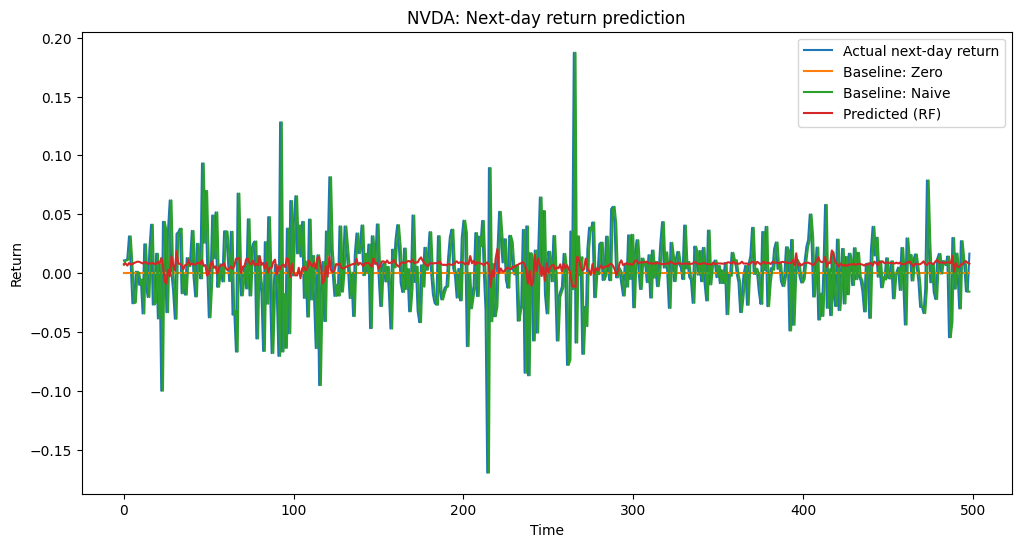

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual next-day return")
plt.plot(pred_zero, label="Baseline: Zero")
plt.plot(pred_naive, label="Baseline: Naive")
plt.plot(pred_rf, label="Predicted (RF)")
plt.title(f"{ticker}: Next-day return prediction")
plt.xlabel("Time")
plt.ylabel("Return")
plt.legend()
plt.show()

In [46]:
latest_X = X.iloc[[-1]]
latest_price = float(feat["price"].iloc[-1])

tomorrow_ret = float(rf.predict(latest_X)[0])
tomorrow_price = latest_price * (1 + tomorrow_ret)

print(f"Latest price: {latest_price:.2f}")
print(f"Predicted next-day return (RF): {tomorrow_ret:.6f}")
print(f"Predicted next-day price (RF): {tomorrow_price:.2f}")

Latest price: 180.25
Predicted next-day return (RF): 0.007858
Predicted next-day price (RF): 181.67


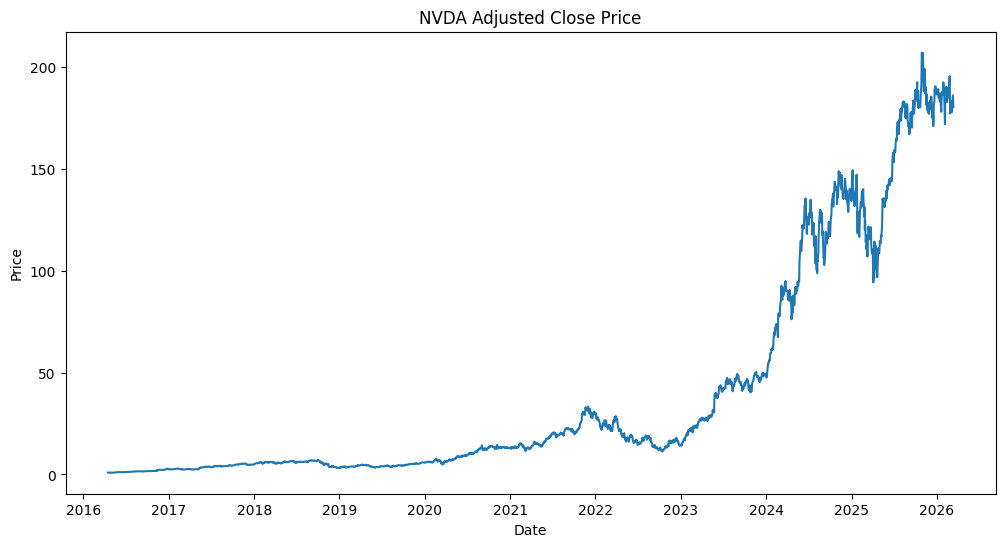

In [47]:
plt.figure(figsize=(12, 6))
plt.plot(feat.index, feat["price"])
plt.title(f"{ticker} Adjusted Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

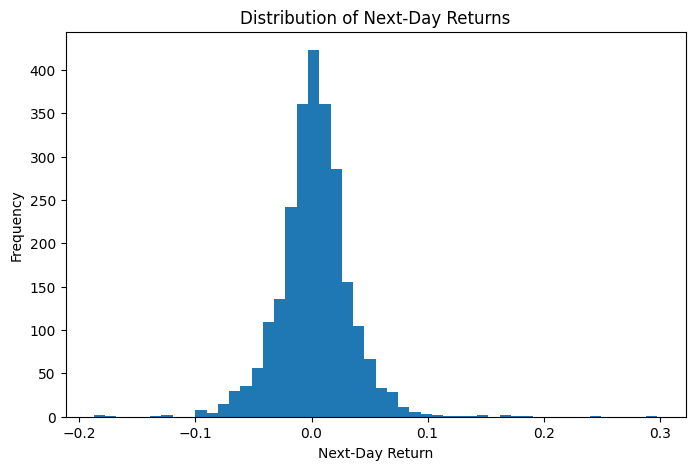

In [48]:
plt.figure(figsize=(8, 5))
plt.hist(feat["target_next_ret"], bins=50)
plt.title("Distribution of Next-Day Returns")
plt.xlabel("Next-Day Return")
plt.ylabel("Frequency")
plt.show()

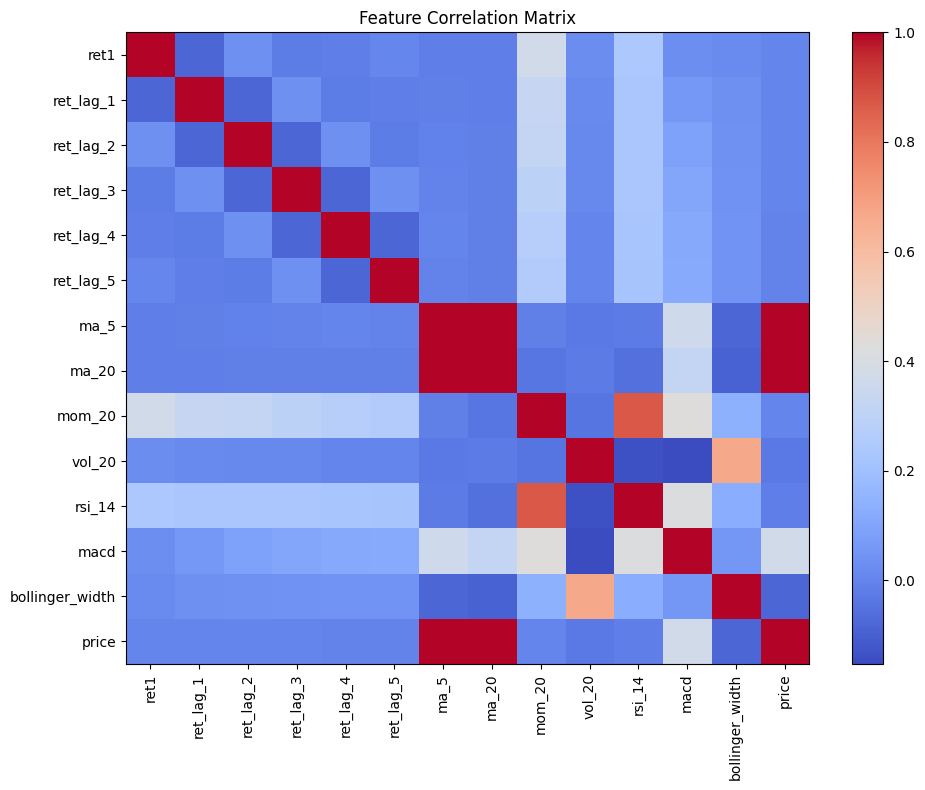

In [49]:
corr = feat.drop(columns=["target_next_ret"]).corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

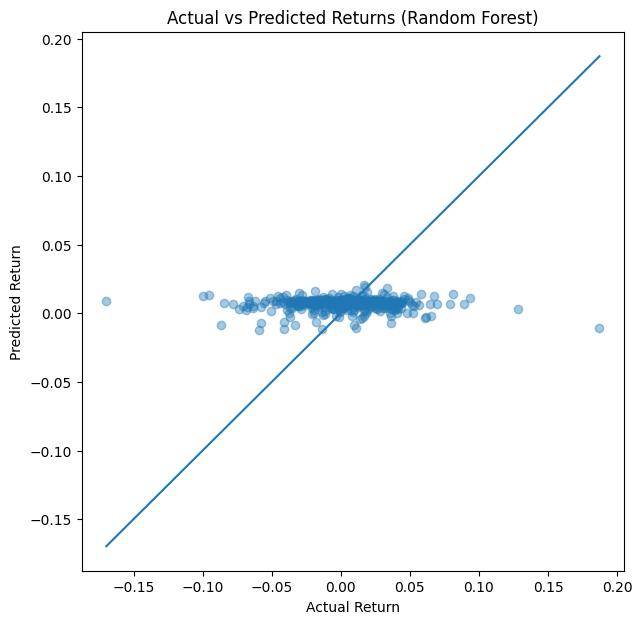

In [50]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_rf, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Actual vs Predicted Returns (Random Forest)")
plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.show()

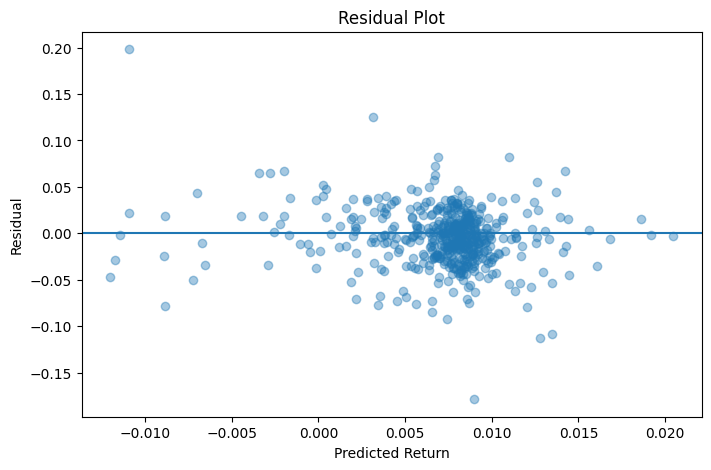

In [51]:
residuals = y_test - pred_rf

plt.figure(figsize=(8, 5))
plt.scatter(pred_rf, residuals, alpha=0.4)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.xlabel("Predicted Return")
plt.ylabel("Residual")
plt.show()

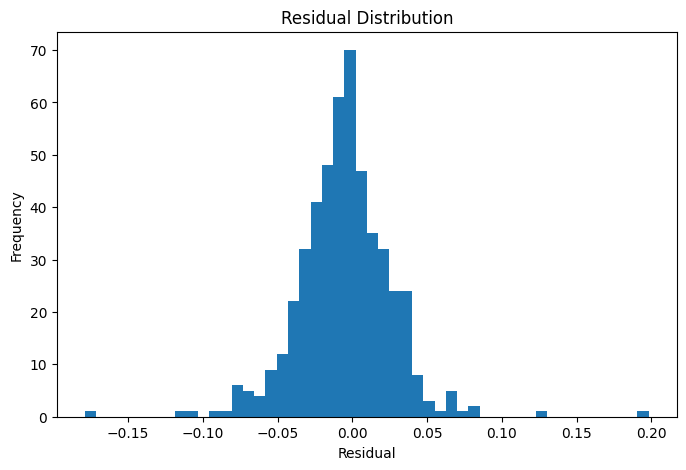

In [52]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

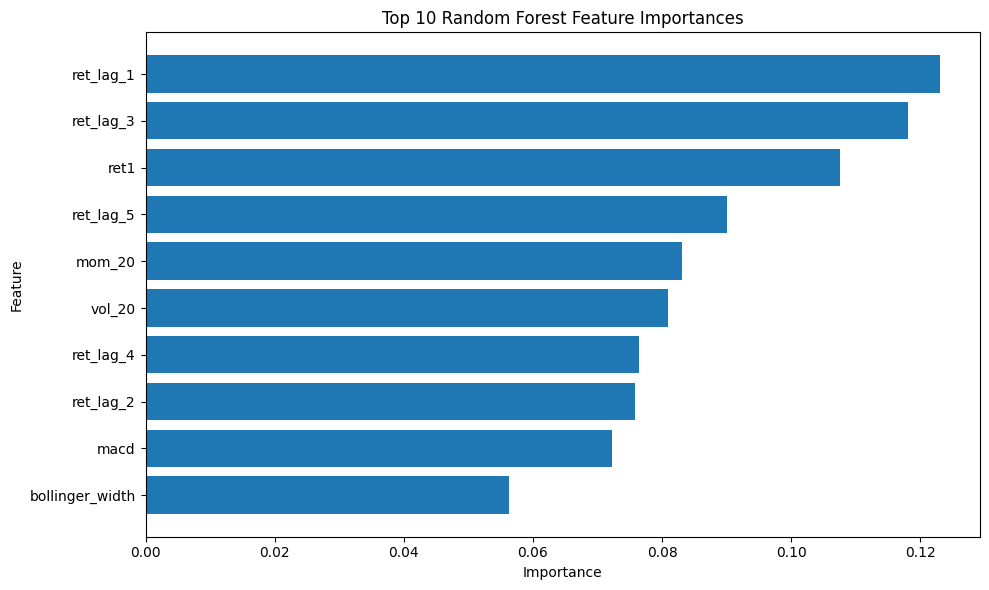

,feature,importance
1,ret_lag_1,0.123078
3,ret_lag_3,0.118120
0,ret1,0.107513
5,ret_lag_5,0.089988
8,mom_20,0.083090
9,vol_20,0.080890
4,ret_lag_4,0.076464
2,ret_lag_2,0.075854
11,macd,0.072215
12,bollinger_width,0.056256


In [53]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

top_features = importance_df.head(10).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

importance_df.head(10)

In [54]:
results_df = pd.DataFrame([
    {
        "Model": "Baseline: Zero return",
        "MAE": mean_absolute_error(y_test, pred_zero),
        "R2": r2_score(y_test, pred_zero),
        "Direction Accuracy": (np.sign(pred_zero) == np.sign(y_test)).mean()
    },
    {
        "Model": "Baseline: Naive",
        "MAE": mean_absolute_error(y_test, pred_naive),
        "R2": r2_score(y_test, pred_naive),
        "Direction Accuracy": (np.sign(pred_naive) == np.sign(y_test)).mean()
    },
    {
        "Model": "Ridge",
        "MAE": mean_absolute_error(y_test, pred_ridge),
        "R2": r2_score(y_test, pred_ridge),
        "Direction Accuracy": (np.sign(pred_ridge) == np.sign(y_test)).mean()
    },
    {
        "Model": "Random Forest",
        "MAE": mean_absolute_error(y_test, pred_rf),
        "R2": r2_score(y_test, pred_rf),
        "Direction Accuracy": (np.sign(pred_rf) == np.sign(y_test)).mean()
    }
])

results_df

,Model,MAE,R2,Direction Accuracy
0,Baseline: Zero return,0.022645,-0.003921,0.000000
1,Baseline: Naive,0.033129,-1.220485,0.454910
2,Ridge,0.023051,-0.037696,0.486974
3,Random Forest,0.022919,-0.046339,0.541082


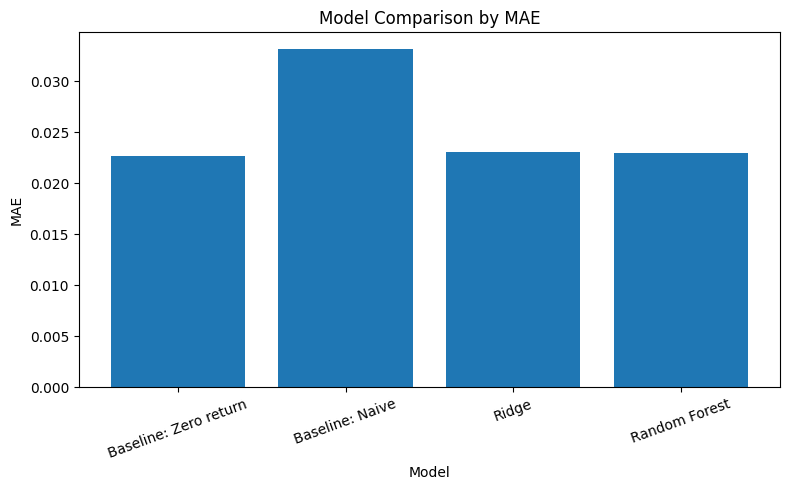

In [55]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [56]:
def macd(price, short=12, long=26):
    ema_short = price.ewm(span=short, adjust=False).mean()
    ema_long = price.ewm(span=long, adjust=False).mean()
    return ema_short - ema_long

In [57]:
def bollinger_width(price, window=20):
    ma = price.rolling(window).mean()
    std = price.rolling(window).std()
    upper = ma + 2 * std
    lower = ma - 2 * std
    return (upper - lower) / ma